In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

In [34]:
df=pd.read_excel('Ice_cream selling data.xlsx')
df

,Temperature (Â°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (Â°C)        49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [22]:
df.corr()

,Temperature (Â°C),Ice Cream Sales (units)
Temperature (Â°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [23]:
x=df.drop(columns='Temperature (Â°C)')#Feature
y=df['Temperature (Â°C)'] #target

In [24]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [25]:
xtrain

,Ice Cream Sales (units)
12,11.218294
4,32.284531
34,7.412094
8,19.226970
3,37.539845
6,22.635401
40,22.839406
41,16.983279
46,34.530743
15,10.957731


In [26]:
ytrain

12   -2.111870
4    -3.578554
34    2.318591
8    -2.672461
3    -3.949661
6    -3.108440
40    3.211366
41    3.270044
46    4.130868
15   -1.326379
9    -2.652287
16   -1.173123
24    0.688781
33    2.075101
30    1.740000
0    -4.662263
43    3.335932
32    1.999310
5    -3.455712
29    1.359813
11   -2.288264
36    2.784836
1    -4.316559
21   -0.033895
2    -4.213985
37    2.831760
35    2.471946
23    0.149245
39    3.020874
10   -2.651498
22    0.008608
18   -0.673753
48    4.899032
20   -0.036156
7    -3.081303
42    3.316073
14   -1.660348
28    1.240712
38    2.959932
Name: Temperature (Â°C), dtype: float64

<Axes: xlabel='Temperature (Â°C)', ylabel='Ice Cream Sales (units)'>

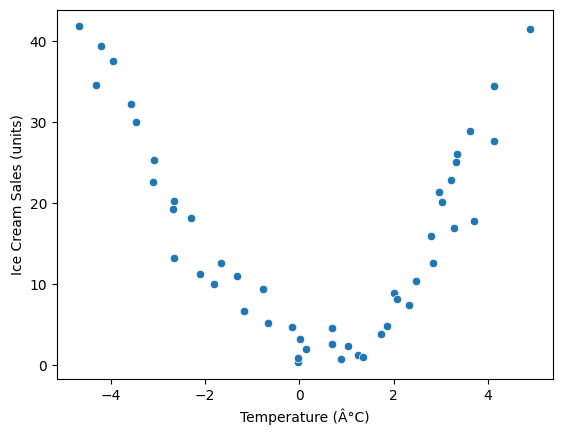

In [27]:
sns.scatterplot(df,x="Temperature (Â°C)",y="Ice Cream Sales (units)")

In [28]:
model=LinearRegression() #model creation
model.fit(xtrain,ytrain)#model training (fit the model) learn the patern(mx+c)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.06]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Ice Cream Sales (units)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.9874
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [29]:
#model evaluation

#train data
ytrain_pred=model.predict(xtrain)
train_score=r2_score(ytrain,ytrain_pred)
print(f'Train Score{train_score}')
#test data
ytest_pred=model.predict(xtest)
test_score=r2_score(ytest,ytest_pred)
print(f'Test Score{test_score}')

Train Score0.0657906381595007
Test Score-0.7491250382996788


In [30]:
poly=PolynomialFeatures(degree=2)
updated_xtrain=poly.fit_transform(xtrain)

In [31]:
updated_xtest=poly.transform(xtest)

In [32]:
model_poly=LinearRegression()
model_poly.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. , 0.02,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.5561
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[3207.44, 22.09, 0. ]"


In [ ]:

#train data
ytrain1_pred=model_poly.predict(updated_xtrain)
train_score=r2_score(ytrain,ytrain1_pred)
print(f'Train Score{train_score}')
#test data
ytest1_pred=model_poly.predict(updated_xtest)
test_score=r2_score(ytest,ytest1_pred)
print(f'Test Score{test_score}')

Train Score0.07533198956934417
Test Score-0.6416499629631229
